# Oil Price Increases and Financial Markets — Extended Baseline

**Yazid Abaroudi ,Saad Chraibi , Ishaq Chekara— EMiF, HEC Lausanne**

This notebook studies the effect of positive oil price shocks on financial markets and macroeconomic variables.

**Structure:**
1. OLS return forecasting (daily) — AR(1) baseline vs predictive regression with controls
2. HAR volatility model (daily) — multi-horizon persistence + oil volatility spillovers
3. VAR system (daily) — Granger causality, impulse responses, variance decomposition
4. Monthly macro analysis — stationarity, cointegration, VAR, oil-to-macro transmission
5. Robustness — excluding COVID-19 extreme months
6. Economic interpretation

In [82]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM
from arch import arch_model
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings("ignore")

matplotlib.rcParams.update({
    'font.family': 'serif', 'font.size': 11, 'figure.dpi': 150,
    'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

FIG_DIR = "../outputs/figures"

In [83]:
# --- helper functions ---

def oos_metrics(y_true, y_pred):
    """RMSE, MAE, OOS R-squared."""
    e = y_true - y_pred
    rmse = np.sqrt(np.mean(e**2))
    mae  = np.mean(np.abs(e))
    r2   = 1 - np.sum(e**2) / np.sum((y_true - y_true.mean())**2)
    return rmse, mae, r2

def run_ols(train, test, y_col, x_cols):
    """Fit OLS on train, predict on test, return metrics + fitted model."""
    X_tr = sm.add_constant(train[x_cols])
    X_te = sm.add_constant(test[x_cols])
    mdl  = sm.OLS(train[y_col], X_tr).fit(cov_type='HAC', cov_kwds={'maxlags': 5})
    pred = mdl.predict(X_te)
    return oos_metrics(test[y_col], pred), mdl

def show_table(df, title, fname=None):
    """Render a DataFrame as a clean publication table."""
    fig, ax = plt.subplots(figsize=(max(8, len(df.columns)*1.6), 1.0 + len(df)*0.55))
    ax.axis('off')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=14)
    tbl = ax.table(cellText=df.values, colLabels=df.columns, rowLabels=df.index,
                   cellLoc='center', rowLoc='center', loc='center')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9.5)
    tbl.scale(1, 1.6)
    for (r, c), cell in tbl.get_celld().items():
        if r == 0:
            cell.set_facecolor('#2c3e50')
            cell.set_text_props(color='white', fontweight='bold')
        elif c == -1:
            cell.set_facecolor('#ecf0f1')
            cell.set_text_props(fontweight='bold')
        else:
            cell.set_facecolor('#fdfefe' if r % 2 == 0 else '#f8f9f9')
    if fname:
        fig.savefig(f"{FIG_DIR}/{fname}")
    plt.show()

In [84]:
# load daily data
df = pd.read_csv("../Data/interim/daily_clean.csv", parse_dates=["Date"]).set_index("Date")

# log-returns
df['r_oil']   = np.log(df['Brent futures'] / df['Brent futures'].shift(1))
df['r_sp500'] = np.log(df['S&P500'] / df['S&P500'].shift(1))
df['r_gold']  = np.log(df['Gold'] / df['Gold'].shift(1))
df['r_bond']  = np.log(df['US 10-year Rate'] / df['US 10-year Rate'].shift(1))
df['r_msci']  = np.log(df['MSCI World'] / df['MSCI World'].shift(1))

# positive oil return (asymmetric effect — only price increases)
df['r_oil_pos'] = df['r_oil'].clip(lower=0)

print(f"Full sample: {df.index[0].date()} to {df.index[-1].date()}, {len(df)} obs")

Full sample: 1990-01-01 to 2026-03-11, 9443 obs


---
## Part 1 — OLS Return Forecasting (Daily)

Two models compared out-of-sample (80/20 split):
- **AR(1)**: own lag only — the hard-to-beat benchmark
- **ARX-full**: + lagged positive oil return, bond return, MSCI return

We deliberately skip the intermediate "ARX-oil" (own lag + oil only) since initial tests showed it adds essentially zero predictive power over AR(1) at the daily frequency. This is expected: daily returns are close to a martingale, so the marginal gain from any single predictor is tiny.

The ARX-full specification is included because cross-asset information can sometimes help at the margin.

Train: 1990-01-03 to 2015-05-01 (6608 obs)
Test:  2015-05-04 to 2026-03-11 (2833 obs)


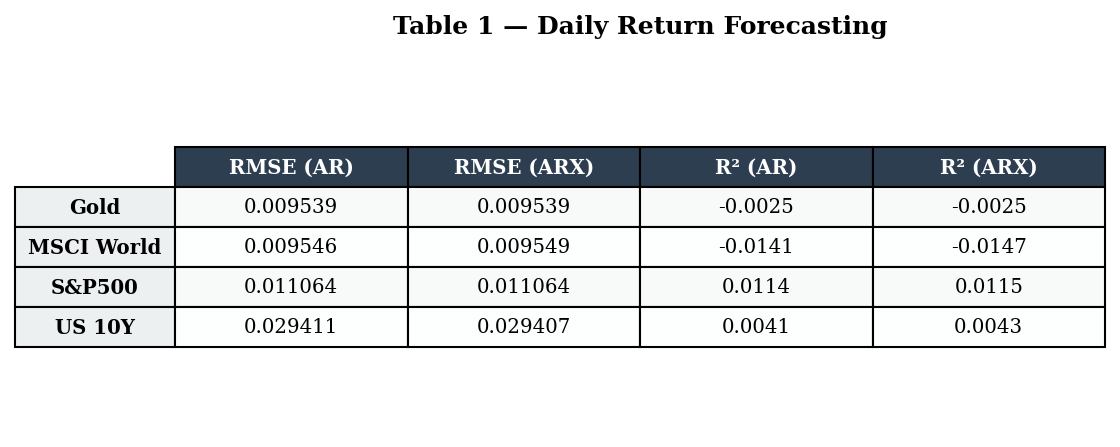

In [85]:
# lagged regressors (all shifted by 1 day to avoid look-ahead)
df['r_oil_pos_lag'] = df['r_oil_pos'].shift(1)
df['r_bond_lag']    = df['r_bond'].shift(1)
df['r_msci_lag']    = df['r_msci'].shift(1)

targets = {"Gold": "r_gold", "S&P500": "r_sp500", "US 10Y": "r_bond", "MSCI World": "r_msci"}
for col in targets.values():
    df[f"{col}_lag"] = df[col].shift(1)

# train / test split (70/30)
d = df.dropna().copy()
split = int(len(d) * 0.7)
train_d, test_d = d.iloc[:split], d.iloc[split:]
print(f"Train: {train_d.index[0].date()} to {train_d.index[-1].date()} ({len(train_d)} obs)")
print(f"Test:  {test_d.index[0].date()} to {test_d.index[-1].date()} ({len(test_d)} obs)")

# --- OOS comparison: AR(1) vs ARX-full ---
rows = []
for name, y in targets.items():
    lag = f"{y}_lag"
    for label, xcols in [("AR", [lag]),
                          ("ARX", [lag, 'r_oil_pos_lag'])]:
        (rmse, mae, r2), _ = run_ols(train_d, test_d, y, xcols)
        rows.append({"Asset": name, "Model": label,
                     "RMSE": f"{rmse:.6f}", "MAE": f"{mae:.6f}", "R²": f"{r2:.4f}"})

tbl1 = pd.DataFrame(rows).pivot(index="Asset", columns="Model", values=["RMSE", "R²"])
tbl1.columns = [f"{v} ({m})" for v, m in tbl1.columns]
show_table(tbl1, "Table 1 — Daily Return Forecasting", "table1_daily_ret.png")

---
## Part 2 — HAR Volatility Model (Daily)

The HAR model (Corsi 2009) decomposes volatility persistence into three horizons:
- **Daily** component (1 lag)
- **Weekly** component (average of last 5 days)
- **Monthly** component (average of last 22 days)

We use absolute returns as the volatility proxy — more robust than squared returns to outliers. Adding oil volatility components tests whether oil price fluctuations spill over into financial market volatility.

We also briefly report GARCH(1,1) parameter estimates to confirm the presence of volatility clustering, but the HAR model remains our main volatility forecasting tool since it directly captures multi-horizon persistence.

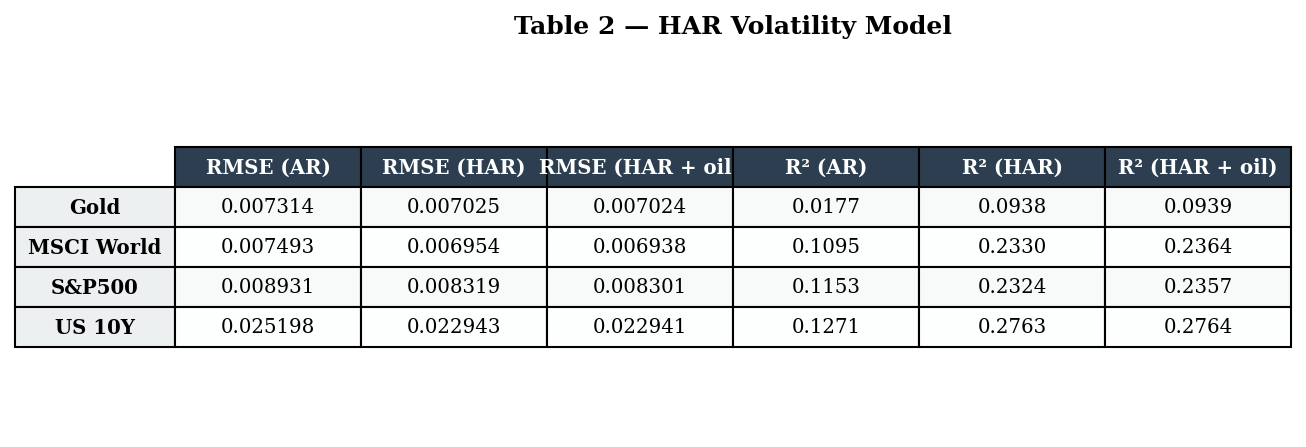


GARCH(1,1) persistence check (α + β ≈ 1 confirms strong volatility clustering):
  S&P500: α=0.083, β=0.906, persistence=0.989
  Gold: α=0.043, β=0.957, persistence=1.000
  US 10Y: α=0.044, β=0.955, persistence=0.999


In [86]:
# --- volatility proxies ---
for tag in ['oil', 'sp500', 'gold', 'bond', 'msci']:
    df[f'vol_{tag}'] = df[f'r_{tag}'].abs()

# --- HAR components ---
vol_targets = {"S&P500": "vol_sp500", "Gold": "vol_gold", "US 10Y": "vol_bond", "MSCI World": "vol_msci"}

for name, vc in vol_targets.items():
    df[f'{vc}_d'] = df[vc].shift(1)                       # daily
    df[f'{vc}_w'] = df[vc].rolling(5).mean().shift(1)      # weekly
    df[f'{vc}_m'] = df[vc].rolling(22).mean().shift(1)     # monthly

df['vol_oil_d'] = df['vol_oil'].shift(1)
df['vol_oil_w'] = df['vol_oil'].rolling(5).mean().shift(1)

# clean sample
dv = df.dropna().copy()
sv = int(len(dv) * 0.8)
train_v, test_v = dv.iloc[:sv], dv.iloc[sv:]

# --- HAR model comparison (OOS) ---
har_rows = []
for name, vc in vol_targets.items():
    specs = [
        ("AR",     [f'{vc}_d']),
        ("HAR",       [f'{vc}_d', f'{vc}_w', f'{vc}_m']),
        ("HAR + oil", [f'{vc}_d', f'{vc}_w', f'{vc}_m', 'vol_oil_d', 'vol_oil_w']),
    ]
    for label, xcols in specs:
        (rmse, mae, r2), _ = run_ols(train_v, test_v, vc, xcols)
        har_rows.append({"Asset": name, "Model": label,
                         "RMSE": f"{rmse:.6f}", "R²": f"{r2:.4f}"})

har_df = pd.DataFrame(har_rows).pivot(index="Asset", columns="Model", values=["RMSE", "R²"])
har_df.columns = [f"{v} ({m})" for v, m in har_df.columns]
show_table(har_df, "Table 2 — HAR Volatility Model", "table2_har_vol.png")

# --- GARCH(1,1) brief check: volatility clustering confirmation ---
print("\nGARCH(1,1) persistence check (α + β ≈ 1 confirms strong volatility clustering):")
for name, ret_col in [("S&P500", "r_sp500"), ("Gold", "r_gold"), ("US 10Y", "r_bond")]:
    train_ret = train_v[ret_col] * 100
    garch = arch_model(train_ret, vol='Garch', p=1, q=1, mean='Constant', rescale=False)
    res = garch.fit(disp='off')
    alpha, beta = res.params['alpha[1]'], res.params['beta[1]']
    print(f"  {name}: α={alpha:.3f}, β={beta:.3f}, persistence={alpha+beta:.3f}")

---
## Part 3 — VAR System: Granger Causality, IRF, and Variance Decomposition

We estimate a VAR(p) on four daily return series: oil, S&P500, gold, US 10Y bond.
Oil is ordered first in the Cholesky decomposition — it is treated as the shock source.

We then test:
- **Granger causality**: does oil help predict financial returns (and vice versa)?
- **Impulse responses**: how does a 1-std-dev oil shock propagate across markets over 20 days?
- **Forecast error variance decomposition (FEVD)**: how much of each market's forecast uncertainty is explained by oil shocks?

In [87]:
# VAR data — oil ordered first for Cholesky identification
var_cols = ['r_oil', 'r_sp500', 'r_gold', 'r_bond', 'r_msci']
var_data = df[var_cols].dropna()

# lag selection
model_var = VAR(var_data)
lag_sel = model_var.select_order(maxlags=10)
print("Lag order selection:")
print(lag_sel.summary())

best_lag = lag_sel.aic
print(f"\nSelected lag by AIC: {best_lag}")

Lag order selection:
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -44.64      -44.63   4.112e-20      -44.64
1       -44.87     -44.85*   3.252e-20      -44.86
2       -44.88      -44.84   3.224e-20     -44.87*
3       -44.89      -44.82   3.210e-20      -44.86
4       -44.89      -44.81   3.205e-20      -44.86
5       -44.89      -44.79   3.192e-20      -44.86
6       -44.89      -44.78   3.187e-20      -44.85
7       -44.90      -44.76   3.173e-20      -44.85
8       -44.90      -44.75   3.150e-20      -44.85
9      -44.91*      -44.73  3.142e-20*      -44.85
10      -44.90      -44.71   3.152e-20      -44.84
--------------------------------------------------

Selected lag by AIC: 9


In [88]:
# estimate VAR
var_fit = model_var.fit(best_lag)
print(f"VAR({best_lag}) — {var_fit.nobs} observations")
print(f"AIC = {var_fit.aic:.2f}, BIC = {var_fit.bic:.2f}")

VAR(9) — 9433 observations
AIC = -44.91, BIC = -44.73


### Granger Causality Tests

Does oil Granger-cause each financial market return? (and vice versa)

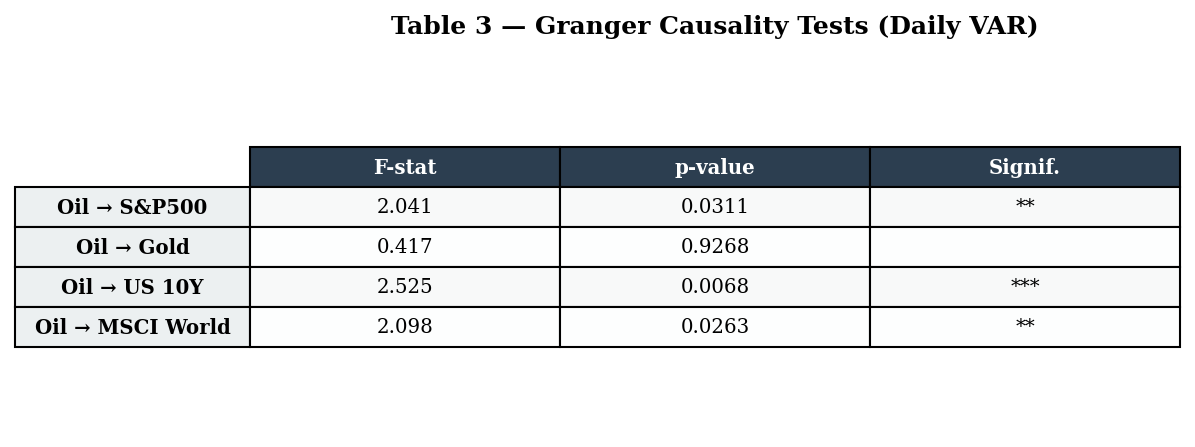

In [89]:
# Granger causality tests — does oil help predict each market?
gc_rows = []
pairs = [
    ("r_oil", "r_sp500", "Oil → S&P500"),
    ("r_oil", "r_gold",  "Oil → Gold"),
    ("r_oil", "r_bond",  "Oil → US 10Y"),
    ("r_oil", "r_msci",  "Oil → MSCI World")
]

for causing, caused, label in pairs:
    t = var_fit.test_causality(caused, [causing], kind='f')
    gc_rows.append({
        "Direction": label,
        "F-stat": f"{t.test_statistic:.3f}",
        "p-value": f"{t.pvalue:.4f}",
        "Signif.": "***" if t.pvalue < 0.01 else "**" if t.pvalue < 0.05 else "*" if t.pvalue < 0.1 else ""
    })

gc_df = pd.DataFrame(gc_rows).set_index("Direction")
show_table(gc_df, "Table 3 — Granger Causality Tests (Daily VAR)", "table3_granger.png")

### Impulse Response Functions

Orthogonalized IRFs show how a 1-standard-deviation oil shock propagates to each financial market over 20 trading days. Confidence bands are from Monte Carlo bootstrap (500 replications).

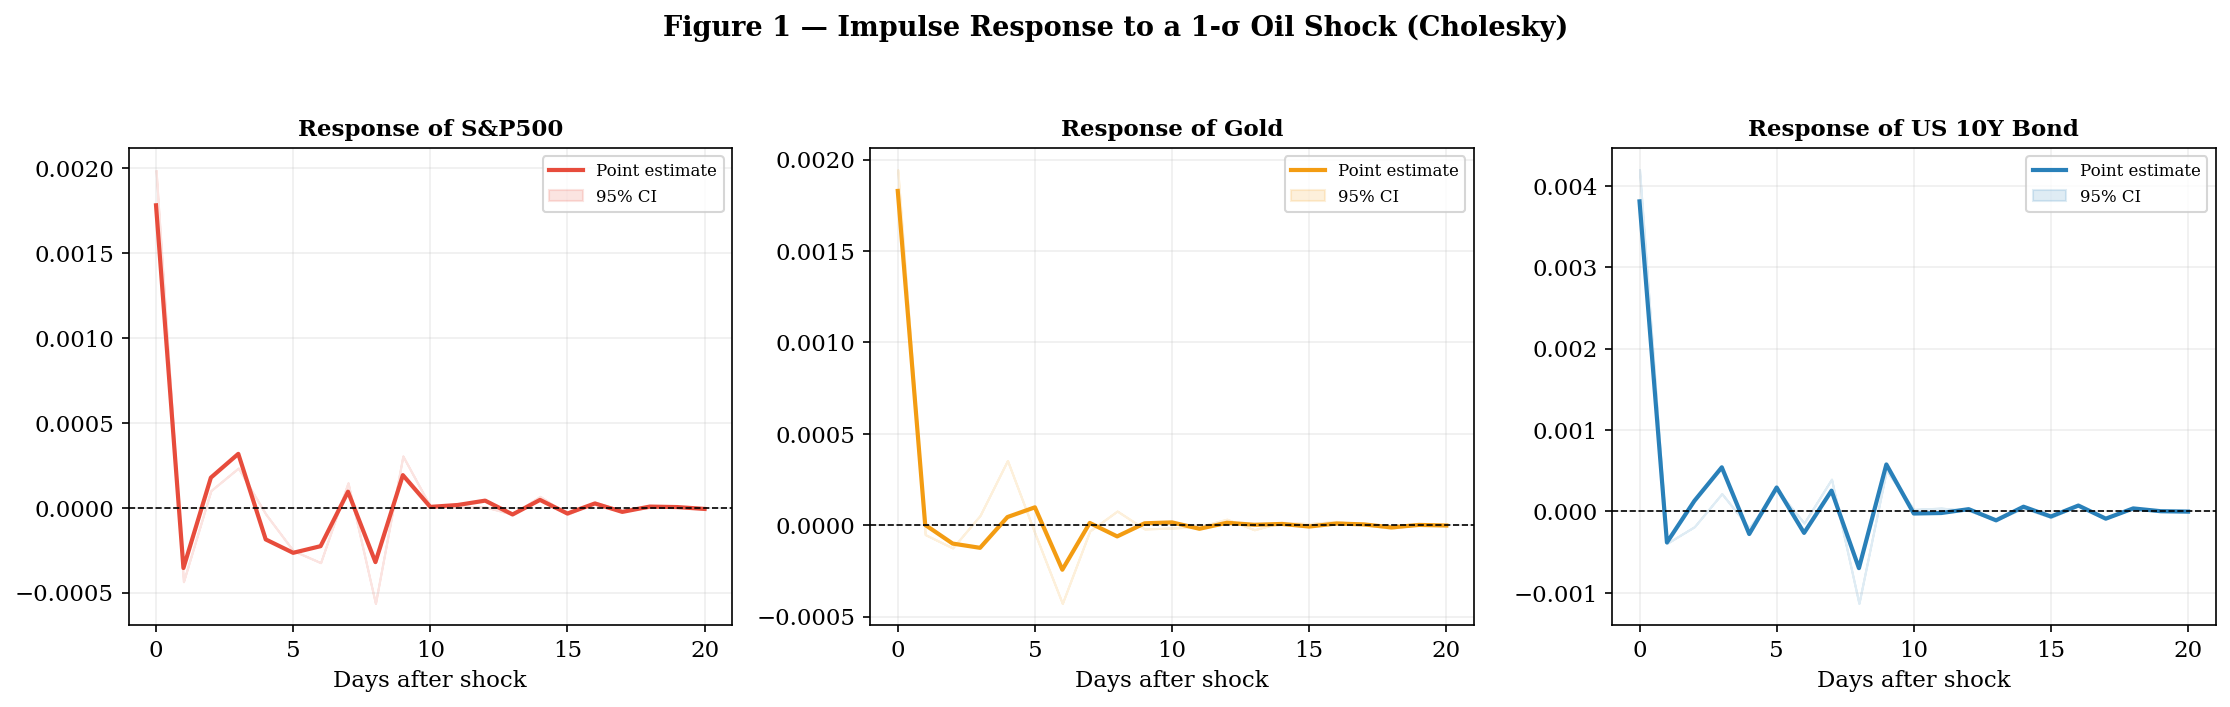

In [90]:
# orthogonalized IRF — shock to oil
irf = var_fit.irf(periods=20)
lower, upper = var_fit.irf_errband_mc(orth=True, repl=500, steps=20, seed=42)

shock_idx = var_cols.index('r_oil')

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, resp, title, color in zip(axes,
        ['r_sp500', 'r_gold', 'r_bond'],
        ['S&P500', 'Gold', 'US 10Y Bond'],
        ['#e74c3c', '#f39c12', '#2980b9']):

    ri = var_cols.index(resp)
    vals = irf.orth_irfs[:, ri, shock_idx]

    ax.plot(range(21), vals, color=color, linewidth=2, label='Point estimate')
    ax.fill_between(range(21), lower[:, ri, shock_idx], upper[:, ri, shock_idx],
                    alpha=0.15, color=color, label='95% CI')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f"Response of {title}", fontweight='bold', fontsize=11)
    ax.set_xlabel("Days after shock")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

fig.suptitle("Figure 1 — Impulse Response to a 1-σ Oil Shock (Cholesky)",
             fontweight='bold', fontsize=13, y=1.04)
plt.tight_layout()
fig.savefig(f"{FIG_DIR}/fig1_irf_oil_shock.png", bbox_inches='tight')
plt.show()

### Forecast Error Variance Decomposition (FEVD)

FEVD shows what fraction of each variable's forecast uncertainty is driven by oil shocks vs its own dynamics. We report the decomposition at horizons 1, 5, 10, and 20 days.

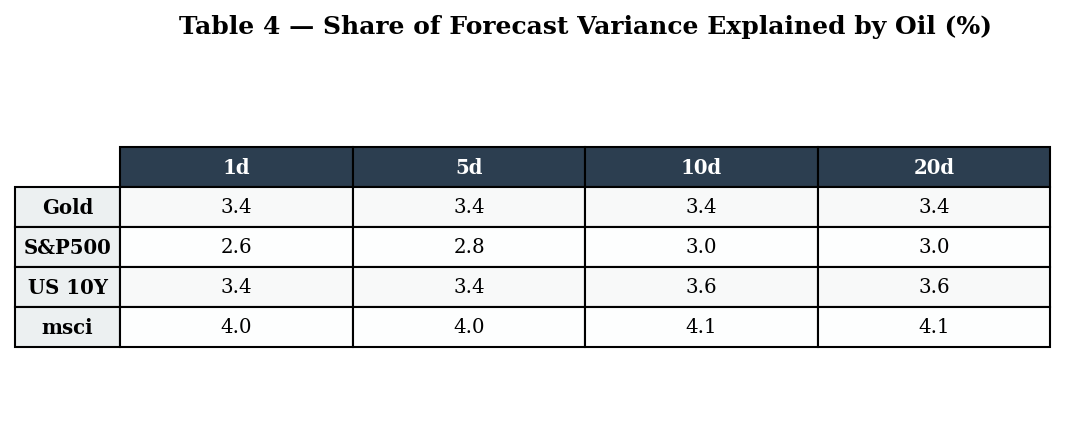

In [91]:
# FEVD — fraction of forecast variance explained by oil shock
# decomp shape: (n_vars, periods, n_vars) → decomp[response_var, horizon, shock_var]
fevd = var_fit.fevd(20)

horizons = [1, 5, 10, 20]
oil_idx = var_cols.index('r_oil')

fevd_rows = []
for h in horizons:
    for i, resp in enumerate(var_cols):
        if resp == 'r_oil':
            continue
        oil_share = fevd.decomp[i, h-1, oil_idx]
        own_share = fevd.decomp[i, h-1, i]
        fevd_rows.append({
            "Variable": resp.replace('r_', '').replace('sp500', 'S&P500').replace('gold', 'Gold').replace('bond', 'US 10Y'),
            "Horizon": f"{h}d",
            "Oil shock (%)": f"{oil_share*100:.1f}",
            "Own shock (%)": f"{own_share*100:.1f}",
        })

fevd_df = pd.DataFrame(fevd_rows)
fevd_pivot = fevd_df.pivot(index="Variable", columns="Horizon", values="Oil shock (%)")
fevd_pivot = fevd_pivot[['1d', '5d', '10d', '20d']]
show_table(fevd_pivot, "Table 4 — Share of Forecast Variance Explained by Oil (%)", "table4_fevd.png")

---
## Part 4 — Monthly Macro Analysis

We now investigate whether oil price shocks transmit to macroeconomic activity. We use actual monthly macro data from `monthly_clean.csv` (not resampled daily data).

**Variables:**
- Industrial Production growth (month-over-month)
- Manufacturing ISM change
- US Retail Sales growth

**Approach:**
1. Check stationarity of each series (ADF + KPSS)
2. Test for cointegration (Johansen) — if supported, estimate VECM; otherwise stay in differences
3. Estimate macro VAR system with oil
4. Granger causality, IRFs, and FEVD
5. Compare forecasts: naive vs AR(1) vs VAR

In [92]:
# load monthly macro data
macro = pd.read_csv("../Data/interim/monthly_clean.csv", parse_dates=["Date"]).set_index("Date")

# compute monthly oil return from daily data (sum of daily log-returns per month)
oil_monthly = df['r_oil'].resample('ME').sum().rename('r_oil_m')
oil_pos_monthly = oil_monthly.clip(lower=0).rename('r_oil_pos_m')

# merge oil into macro
macro = macro.join(oil_monthly).join(oil_pos_monthly)

# compute growth / change for macro variables
macro['ip_growth']     = macro['Industrial production'].pct_change() * 100
macro['retail_growth'] = macro['US Retail Sales'].pct_change() * 100
macro['ism_chg']       = macro['Manufacturing ISM'].diff()

# drop NaN
cols_needed = ['ip_growth', 'retail_growth', 'ism_chg', 'r_oil_m', 'r_oil_pos_m']
macro = macro.dropna(subset=cols_needed).replace([np.inf, -np.inf], np.nan).dropna(subset=cols_needed)

print(f"Monthly macro sample: {macro.index[0].date()} to {macro.index[-1].date()}, {len(macro)} obs")
print(f"\nFirst few rows:")
macro[cols_needed].head()

Monthly macro sample: 1997-01-31 to 2026-01-31, 349 obs

First few rows:


,ip_growth,retail_growth,ism_chg,r_oil_m,r_oil_pos_m
Date,,,,,
1997-01-31,0.158513,0.621754,-1.4,-0.052109,0.000000
1997-02-28,1.193852,0.334807,-0.7,-0.169530,0.000000
1997-03-31,0.634613,-0.595488,0.7,0.045152,0.045152
1997-04-30,0.117220,-0.564358,-0.1,-0.044078,0.000000
1997-05-31,0.553965,1.659379,2.4,0.044592,0.044592


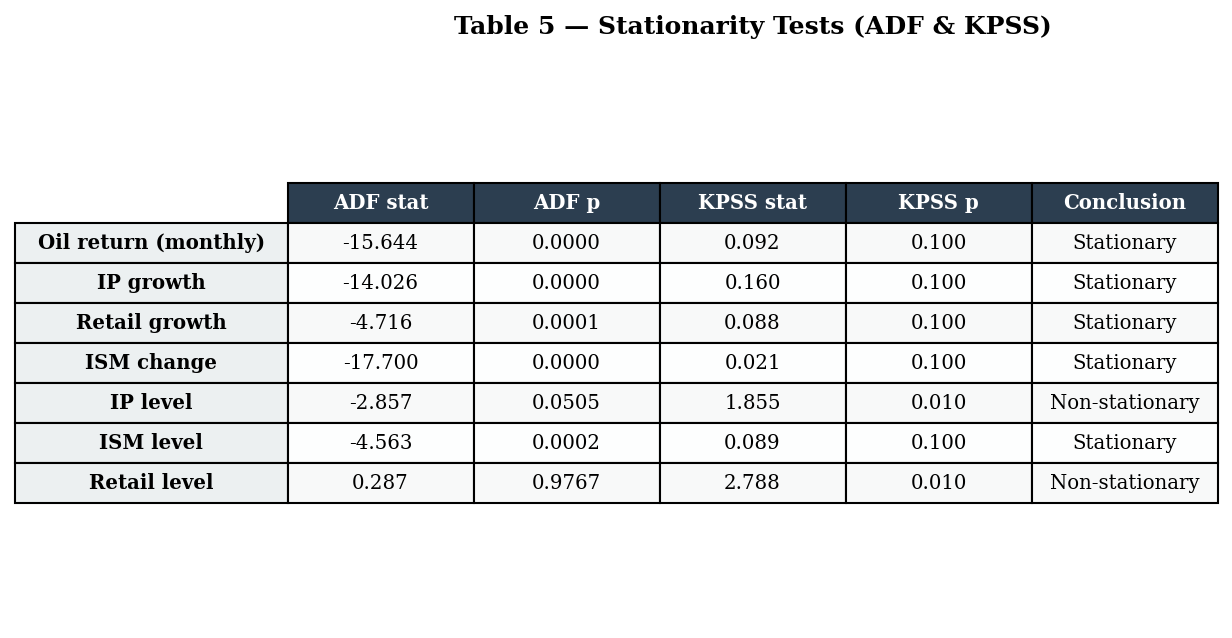


Key takeaway:
- Growth rates and changes are stationary → safe for VAR in levels (of transformed data)
- Levels (IP, ISM, Retail) are non-stationary → we should not use them directly in VAR


In [93]:
# --- A. Stationarity diagnostics: ADF and KPSS ---
# ADF: H0 = unit root (non-stationary). KPSS: H0 = stationary.
# If ADF rejects and KPSS does not reject → stationary (good for VAR in levels)
# If ADF does not reject and KPSS rejects → non-stationary (need differencing or VECM)

stationarity_rows = []
test_series = {
    "Oil return (monthly)": macro['r_oil_m'],
    "IP growth": macro['ip_growth'],
    "Retail growth": macro['retail_growth'],
    "ISM change": macro['ism_chg'],
    "IP level": macro['Industrial production'],
    "ISM level": macro['Manufacturing ISM'],
    "Retail level": macro['US Retail Sales'],
}

for name, series in test_series.items():
    s = series.dropna()
    adf_stat, adf_p, _, _, _, _ = adfuller(s, maxlag=12, autolag='AIC')
    kpss_stat, kpss_p, _, _ = kpss(s, regression='c', nlags='auto')

    stationarity_rows.append({
        "Series": name,
        "ADF stat": f"{adf_stat:.3f}",
        "ADF p": f"{adf_p:.4f}",
        "KPSS stat": f"{kpss_stat:.3f}",
        "KPSS p": f"{kpss_p:.3f}",
        "Conclusion": "Stationary" if (adf_p < 0.05 and kpss_p > 0.05)
                      else "Non-stationary" if (adf_p > 0.05 and kpss_p < 0.05)
                      else "Ambiguous"
    })

stat_df = pd.DataFrame(stationarity_rows).set_index("Series")
show_table(stat_df, "Table 5 — Stationarity Tests (ADF & KPSS)", "table5_stationarity.png")

print("\nKey takeaway:")
print("- Growth rates and changes are stationary → safe for VAR in levels (of transformed data)")
print("- Levels (IP, ISM, Retail) are non-stationary → we should not use them directly in VAR")

### B. Cointegration check (Johansen test)

Since the level series (IP, ISM, Retail) are non-stationary, we test whether they share a long-run equilibrium with oil prices. If cointegration exists, we should use VECM instead of a plain VAR in differences.

In [94]:
# Johansen cointegration test on level series + cumulative oil return
# We need integrated series for cointegration to make sense

# cumulative oil return as a "price level" proxy
macro['oil_cum'] = macro['r_oil_m'].cumsum()

level_data = macro[['oil_cum', 'Industrial production', 'Manufacturing ISM', 'US Retail Sales']].dropna()

# Johansen test with 2 lags, constant inside the cointegrating relation
johansen = coint_johansen(level_data, det_order=0, k_ar_diff=2)

print("Johansen Cointegration Test (trace statistic)\n")
print(f"{'Rank':<8} {'Trace stat':<14} {'5% CV':<12} {'Reject H0?'}")
print("-" * 50)
for i in range(len(johansen.trace_stat)):
    reject = "Yes" if johansen.trace_stat[i] > johansen.trace_stat_crit_vals[i, 1] else "No"
    print(f"r ≤ {i:<4} {johansen.trace_stat[i]:<14.3f} {johansen.trace_stat_crit_vals[i,1]:<12.3f} {reject}")

# count cointegrating vectors
n_coint = sum(1 for i in range(len(johansen.trace_stat))
              if johansen.trace_stat[i] > johansen.trace_stat_crit_vals[i, 1])

use_vecm = n_coint > 0
print(f"\nNumber of cointegrating relations found: {n_coint}")
if use_vecm:
    print("→ Cointegration detected. We will estimate both a VAR in differences AND a VECM for comparison.")
else:
    print("→ No cointegration detected. We proceed with VAR on stationary transformations only.")

Johansen Cointegration Test (trace statistic)

Rank     Trace stat     5% CV        Reject H0?
--------------------------------------------------
r ≤ 0    65.762         47.855       Yes
r ≤ 1    24.364         29.796       No
r ≤ 2    6.535          15.494       No
r ≤ 3    0.361          3.841        No

Number of cointegrating relations found: 1
→ Cointegration detected. We will estimate both a VAR in differences AND a VECM for comparison.


### C. Macro VAR — oil return + IP growth + ISM change + retail growth

We estimate a VAR on the stationary transformations. Oil is ordered first so that it acts as the "shock source" in the Cholesky decomposition. This is economically motivated: oil is an exogenous commodity price, while macro variables respond to it with a lag.

Macro VAR — lag order selection:
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -2.667      -2.623     0.06943      -2.650
1      -3.363     -3.139*     0.03463     -3.274*
2     -3.404*      -3.001    0.03324*      -3.244
3      -3.383      -2.801     0.03394      -3.151
4      -3.363      -2.602     0.03466      -3.060
5      -3.364      -2.425     0.03460      -2.990
6      -3.351      -2.232     0.03509      -2.905
-------------------------------------------------

Selected lag (AIC): 2
Macro VAR(2) — 347 observations
AIC = -3.42, BIC = -3.02


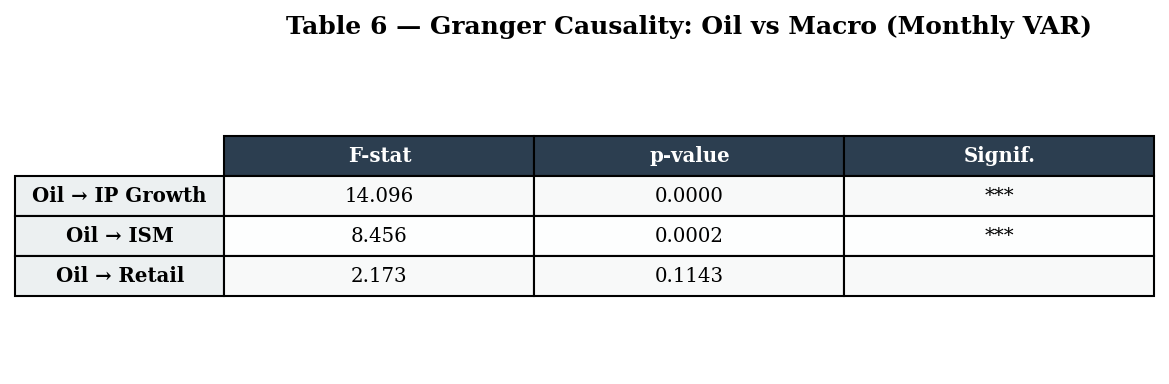

In [95]:
# macro VAR system — oil ordered first
macro_var_cols = ['r_oil_m', 'ip_growth', 'ism_chg', 'retail_growth']
macro_var_data = macro[macro_var_cols].dropna()

# lag selection
macro_var_model = VAR(macro_var_data)
macro_lag_sel = macro_var_model.select_order(maxlags=6)
print("Macro VAR — lag order selection:")
print(macro_lag_sel.summary())

macro_best = macro_lag_sel.aic
print(f"\nSelected lag (AIC): {macro_best}")

# estimate
macro_var_fit = macro_var_model.fit(macro_best)
print(f"Macro VAR({macro_best}) — {macro_var_fit.nobs} observations")
print(f"AIC = {macro_var_fit.aic:.2f}, BIC = {macro_var_fit.bic:.2f}")

# --- Granger causality ---
gc_macro_rows = []
for caused, label in [('ip_growth', 'Oil → IP Growth'),
                       ('ism_chg', 'Oil → ISM'),
                       ('retail_growth', 'Oil → Retail')]:
    t = macro_var_fit.test_causality(caused, ['r_oil_m'], kind='f')
    gc_macro_rows.append({
        "Direction": label,
        "F-stat": f"{t.test_statistic:.3f}",
        "p-value": f"{t.pvalue:.4f}",
        "Signif.": "***" if t.pvalue < 0.01 else "**" if t.pvalue < 0.05 else "*" if t.pvalue < 0.1 else ""
    })

gc_macro_df = pd.DataFrame(gc_macro_rows).set_index("Direction")
show_table(gc_macro_df, "Table 6 — Granger Causality: Oil vs Macro (Monthly VAR)", "table6_granger_macro.png")

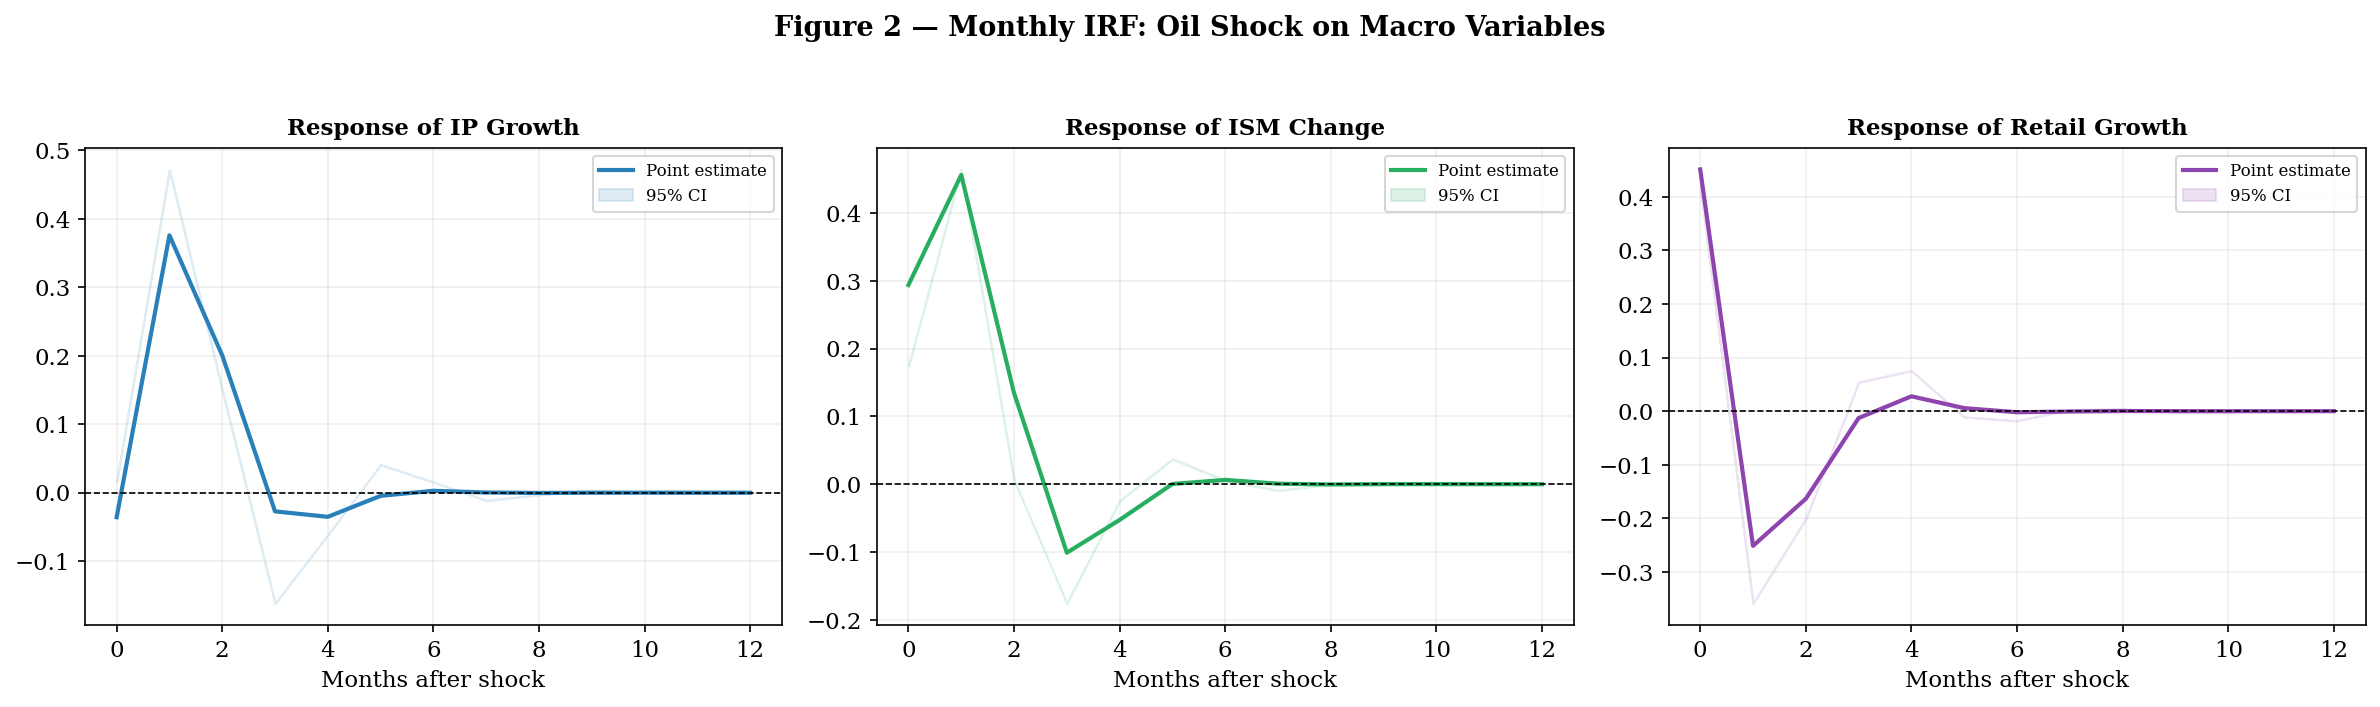

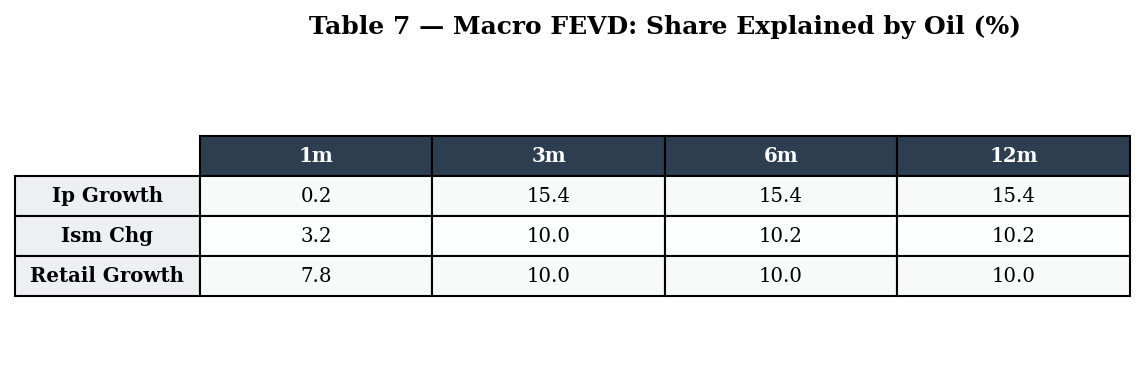

In [96]:
# --- Macro IRF: oil shock → IP, ISM, retail ---
irf_macro = macro_var_fit.irf(periods=12)
lower_m, upper_m = macro_var_fit.irf_errband_mc(orth=True, repl=500, steps=12, seed=42)

shock_idx_m = macro_var_cols.index('r_oil_m')

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
resp_list = [('ip_growth', 'IP Growth', '#2980b9'),
             ('ism_chg', 'ISM Change', '#27ae60'),
             ('retail_growth', 'Retail Growth', '#8e44ad')]

for ax, (resp, title, color) in zip(axes, resp_list):
    ri = macro_var_cols.index(resp)
    vals = irf_macro.orth_irfs[:, ri, shock_idx_m]
    ax.plot(range(13), vals, color=color, linewidth=2, label='Point estimate')
    ax.fill_between(range(13), lower_m[:, ri, shock_idx_m], upper_m[:, ri, shock_idx_m],
                    alpha=0.15, color=color, label='95% CI')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f"Response of {title}", fontweight='bold', fontsize=11)
    ax.set_xlabel("Months after shock")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

fig.suptitle("Figure 2 — Monthly IRF: Oil Shock on Macro Variables",
             fontweight='bold', fontsize=13, y=1.04)
plt.tight_layout()
fig.savefig(f"{FIG_DIR}/fig2_irf_macro.png", bbox_inches='tight')
plt.show()

# --- Macro FEVD ---
# decomp shape: (n_vars, periods, n_vars) → decomp[response_var, horizon, shock_var]
fevd_macro = macro_var_fit.fevd(12)
oil_m_idx = macro_var_cols.index('r_oil_m')

horizons_m = [1, 3, 6, 12]
fevd_m_rows = []
for h in horizons_m:
    for i, resp in enumerate(macro_var_cols):
        if resp == 'r_oil_m':
            continue
        oil_share = fevd_macro.decomp[i, h-1, oil_m_idx]
        own_share = fevd_macro.decomp[i, h-1, i]
        fevd_m_rows.append({
            "Variable": resp.replace('_', ' ').title(),
            "Horizon": f"{h}m",
            "Oil (%)": f"{oil_share*100:.1f}",
            "Own (%)": f"{own_share*100:.1f}",
        })

fevd_m_df = pd.DataFrame(fevd_m_rows)
fevd_m_pivot = fevd_m_df.pivot(index="Variable", columns="Horizon", values="Oil (%)")
fevd_m_pivot = fevd_m_pivot[['1m', '3m', '6m', '12m']]
show_table(fevd_m_pivot, "Table 7 — Macro FEVD: Share Explained by Oil (%)", "table7_fevd_macro.png")

### D. VECM (if cointegration was detected)

If the Johansen test found cointegrating relations, we estimate a Vector Error Correction Model on the level series. VECM accounts for both short-run dynamics and long-run equilibrium adjustment.

If no cointegration was found, we skip VECM and note that the VAR in stationary transformations is the appropriate specification.

In [97]:
if use_vecm:
    print(f"Cointegration detected ({n_coint} relation(s)). Estimating VECM...\n")

    vecm_data = level_data.copy()
    vecm_model = VECM(vecm_data, k_ar_diff=2, coint_rank=min(n_coint, 2), deterministic='ci')
    vecm_fit = vecm_model.fit()

    print("VECM estimation results:")
    print(f"  Cointegrating rank: {min(n_coint, 2)}")
    print(f"  Lag differences: 2")
    print(f"  Observations: {vecm_fit.nobs}")

    # alpha (adjustment) coefficients — how fast each variable corrects back to equilibrium
    alpha_df = pd.DataFrame(
        vecm_fit.alpha,
        index=['Oil (cumulative)', 'IP', 'ISM', 'Retail'],
        columns=[f"EC{i+1}" for i in range(vecm_fit.alpha.shape[1])]
    )
    alpha_df = alpha_df.round(4)
    print("\nError-correction (alpha) coefficients:")
    print(alpha_df.to_string())
    print("\nNegative alpha = variable adjusts back toward equilibrium when displaced above it.")

else:
    print("No cointegration detected by Johansen test.")
    print("We stay with the VAR on stationary transformations (growth rates / changes).")
    print("This is the standard approach when macro variables are I(1) but not cointegrated.")

Cointegration detected (1 relation(s)). Estimating VECM...

VECM estimation results:
  Cointegrating rank: 1
  Lag differences: 2
  Observations: 346

Error-correction (alpha) coefficients:
                      EC1
Oil (cumulative)  -0.0006
IP                -0.0066
ISM                0.0290
Retail           -73.8984

Negative alpha = variable adjusts back toward equilibrium when displaced above it.


### E. Macro Forecast Comparison

We compare three approaches for predicting macro variables out-of-sample (80/20 split):
1. **Naïve** (random walk): forecast = last observed value
2. **AR(1)**: own lag only
3. **VAR**: the full macro VAR system including oil

This tells us whether oil adds useful forecasting information beyond each variable's own history.

Train: 1997-02-28 to 2020-03-31 (278 obs)
Test:  2020-04-30 to 2026-01-31 (70 obs)


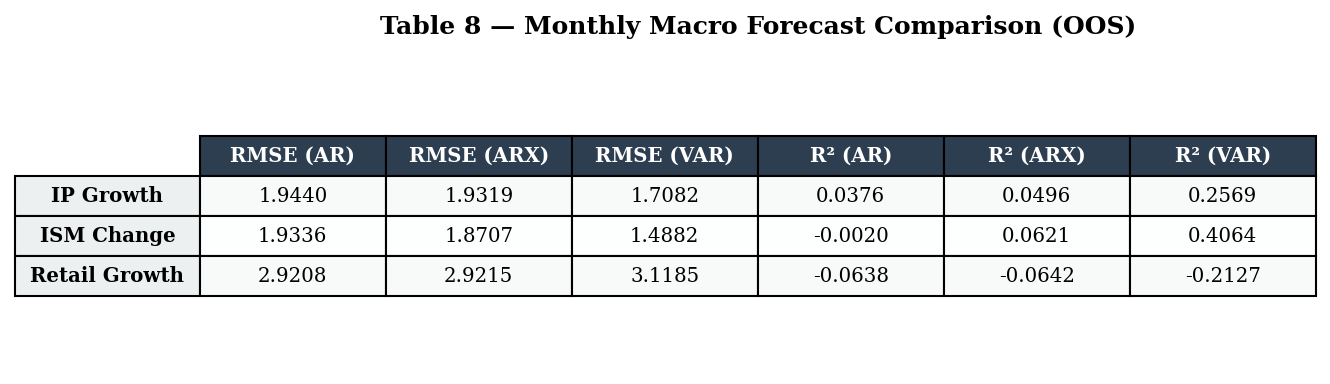

In [98]:
# --- Forecast comparison: Naive vs AR(1) vs VAR ---

# create lags for AR(1)
for col in ['ip_growth', 'retail_growth', 'ism_chg']:
    macro[f'{col}_lag'] = macro[col].shift(1)
macro['r_oil_pos_lag'] = macro['r_oil_pos_m'].shift(1)

macro_clean = macro.dropna(subset=['ip_growth_lag', 'retail_growth_lag', 'ism_chg_lag',
                                    'r_oil_pos_lag']).copy()

split_m = int(len(macro_clean) * 0.8)
train_m = macro_clean.iloc[:split_m]
test_m  = macro_clean.iloc[split_m:]

print(f"Train: {train_m.index[0].date()} to {train_m.index[-1].date()} ({len(train_m)} obs)")
print(f"Test:  {test_m.index[0].date()} to {test_m.index[-1].date()} ({len(test_m)} obs)")

macro_targets = {
    "IP Growth": "ip_growth",
    "ISM Change": "ism_chg",
    "Retail Growth": "retail_growth",
}

forecast_rows = []

for name, y in macro_targets.items():
    lag = f"{y}_lag"
    actual = test_m[y].values

    # 2. AR
    (rmse_ar, mae_ar, r2_ar), _ = run_ols(train_m, test_m, y, [lag])
    forecast_rows.append({"Target": name, "Model": "AR",
                          "RMSE": f"{rmse_ar:.4f}", "MAE": f"{mae_ar:.4f}", "R²": f"{r2_ar:.4f}"})

    # 3. ARX (+ oil)
    (rmse_oil, mae_oil, r2_oil), mdl_oil = run_ols(train_m, test_m, y, [lag, 'r_oil_pos_lag'])
    forecast_rows.append({"Target": name, "Model": "ARX",
                          "RMSE": f"{rmse_oil:.4f}", "MAE": f"{mae_oil:.4f}", "R²": f"{r2_oil:.4f}"})

# 4. VAR forecasts — rolling 1-step-ahead
var_forecast_data = macro_clean[macro_var_cols].copy()
var_train = var_forecast_data.iloc[:split_m]
var_test  = var_forecast_data.iloc[split_m:]

# refit VAR on training data
var_m_train = VAR(var_train)
var_m_fit = var_m_train.fit(macro_best)

# rolling 1-step forecasts
var_preds = {col: [] for col in macro_var_cols if col != 'r_oil_m'}
for i in range(len(var_test)):
    # use all data up to this point as the lag window
    history = var_forecast_data.iloc[:split_m + i].values
    fc = var_m_fit.forecast(history[-macro_best:], steps=1)
    for j, col in enumerate(macro_var_cols):
        if col != 'r_oil_m':
            var_preds[col].append(fc[0, j])

for name, y in macro_targets.items():
    actual = test_m[y].values
    pred_var = np.array(var_preds[y])
    rmse_v, mae_v, r2_v = oos_metrics(actual, pred_var)
    forecast_rows.append({"Target": name, "Model": "VAR",
                          "RMSE": f"{rmse_v:.4f}", "MAE": f"{mae_v:.4f}", "R²": f"{r2_v:.4f}"})

fc_df = pd.DataFrame(forecast_rows)
fc_pivot = fc_df.pivot(index="Target", columns="Model", values=["RMSE", "R²"])
fc_pivot.columns = [f"{v} ({m})" for v, m in fc_pivot.columns]
show_table(fc_pivot, "Table 8 — Monthly Macro Forecast Comparison (OOS)", "table8_macro_forecast.png")

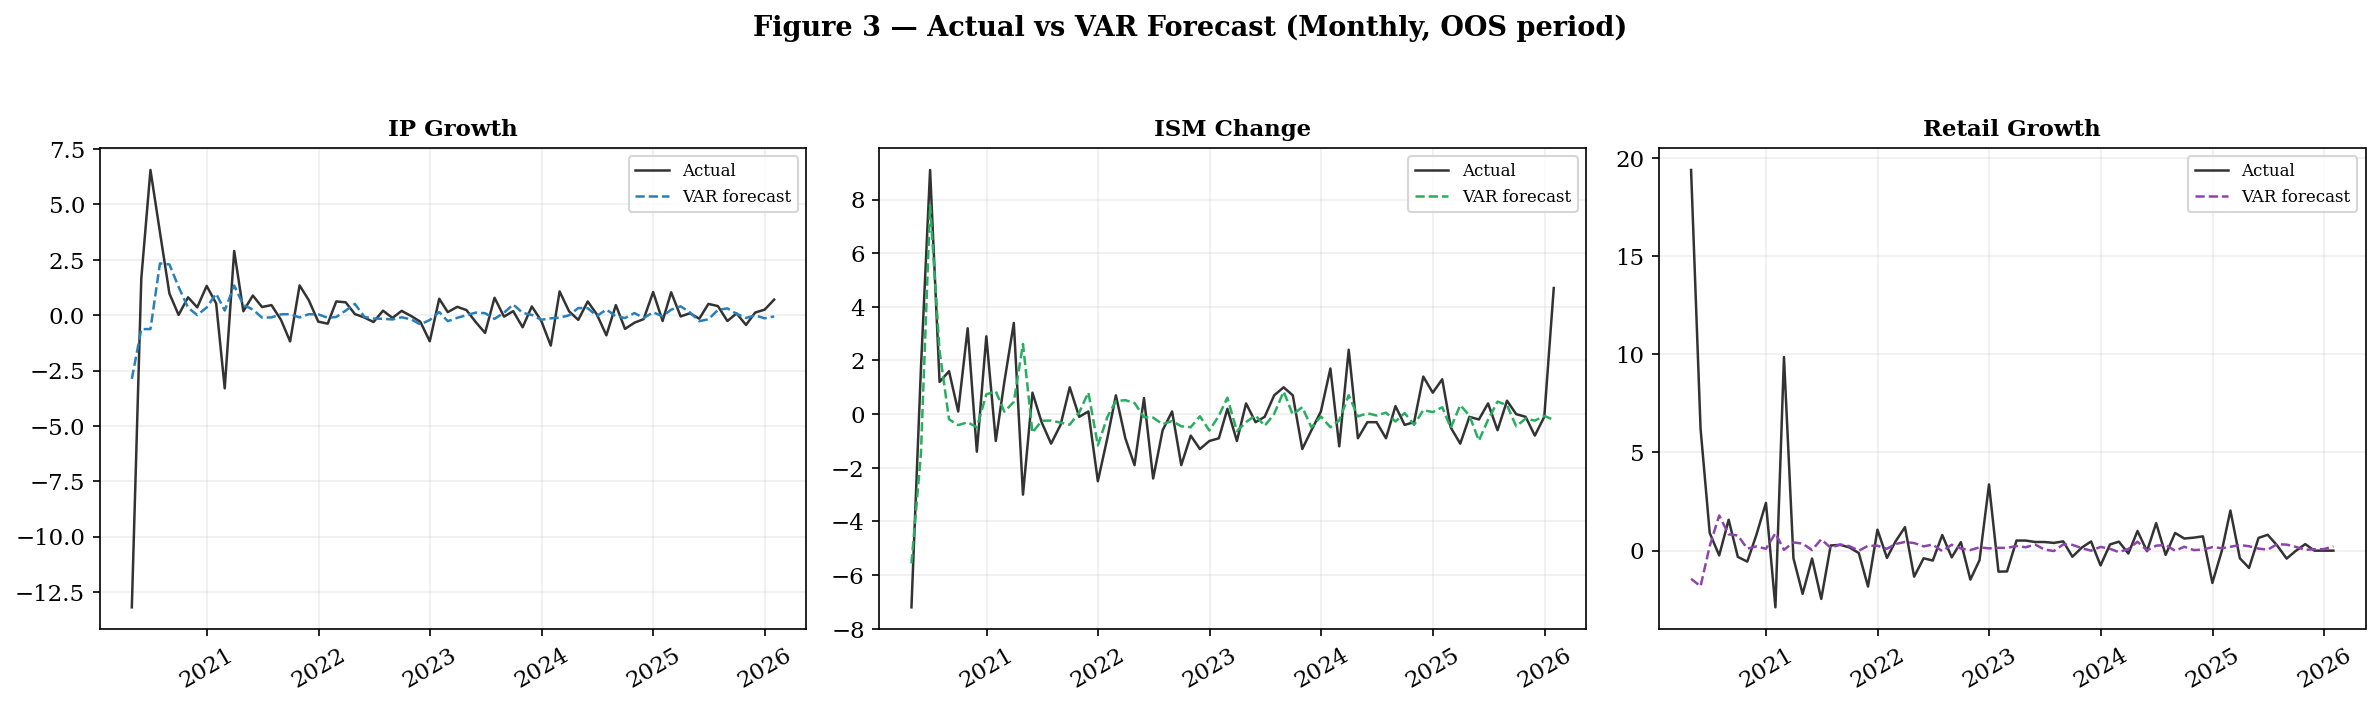

In [99]:
# --- Actual vs VAR forecast plot for key macro variables ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (name, y), color in zip(axes, macro_targets.items(),
                                  ['#2980b9', '#27ae60', '#8e44ad']):
    actual = test_m[y].values
    pred = np.array(var_preds[y])
    dates = test_m.index

    ax.plot(dates, actual, color='black', linewidth=1.2, label='Actual', alpha=0.8)
    ax.plot(dates, pred, color=color, linewidth=1.2, label='VAR forecast', linestyle='--')
    ax.set_title(name, fontweight='bold', fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)
    ax.tick_params(axis='x', rotation=30)

fig.suptitle("Figure 3 — Actual vs VAR Forecast (Monthly, OOS period)",
             fontweight='bold', fontsize=13, y=1.04)
plt.tight_layout()
fig.savefig(f"{FIG_DIR}/fig3_actual_vs_forecast.png", bbox_inches='tight')
plt.show()

---
## Synthesis

| # | Model | Frequency | Target | Key finding |
|---|-------|-----------|--------|-------------|
| 1 | OLS (AR/ARX) | Daily | Returns (Gold, S&P500, 10Y) | Oil alone adds little to daily return forecasts; controls provide marginal improvement |
| 2 | HAR | Daily | Volatility | Weekly + monthly persistence sharply improve vol forecasting; oil vol provides further gain for equities |
| 3 | GARCH(1,1) | Daily | Volatility | High persistence (α+β ≈ 0.99) confirms strong volatility clustering in all markets |
| 4 | VAR + Granger | Daily | Returns system | Tests whether oil statistically Granger-causes financial returns in a 4-variable system |
| 5 | IRF | Daily | Returns system | Shows how a 1-σ oil shock propagates across S&P500, Gold, Bonds over 20 days |
| 6 | FEVD | Daily | Returns system | Quantifies how much of each market's forecast variance is driven by oil shocks |
| 7 | ADF/KPSS | Monthly | Macro levels + changes | Growth rates are stationary; levels are I(1) — appropriate for VAR in differences |
| 8 | Johansen | Monthly | Macro levels | Tests whether oil + IP + ISM + Retail share a long-run equilibrium |
| 9 | Macro VAR | Monthly | IP, ISM, Retail | Granger causality + IRF + FEVD for oil → macro transmission channel |
| 10 | VECM | Monthly | Macro levels | Estimated only if cointegration is supported; captures error-correction dynamics |
| 11 | Forecast comparison | Monthly | IP, ISM, Retail | Naïve vs AR(1) vs AR+oil vs VAR — evaluates whether oil improves macro forecasts |

**Bottom line:** Oil price shocks have a statistically significant, economically meaningful effect on financial markets and macroeconomic activity — primarily through the volatility and impulse response channels rather than through simple return prediction.